# Section 6 — Inférence et Décodage

**Fichiers sources** : `decoder.py`, `inference_decoder.py`

---

## Du modèle entraîné à une solution complète

Le modèle produit des **logits** à chaque étape. Mais une solution VRPTW est une séquence de décisions enchaînées. Le **décodeur** orchestre cette construction :

```
Modèle entraîné (best_model.pt)
        ↓
TorchModelScorer  ←→  decoder.py
        ↓
DecodeResult  →  routes, coût, clients servis
```

Deux stratégies de décodage :
- **Greedy** : à chaque étape, prendre `argmax(logits)` → rapide mais sous-optimal
- **Beam Search W=20** : garder 20 solutions partielles en parallèle → meilleur coût

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from preprocess import generate_instance
from oracle import resoudre_instance
from decoder import (
    decode_vrptw_with_repair,
    decode_vrptw_beam_search,
    verify_solution,
    feasible_clients,
)
from inference_decoder import load_trained_model, TorchModelScorer

SEED = 42
N    = 10
instance = generate_instance(n=N, seed=SEED)

model  = load_trained_model('artifacts_train_small/best_model.pt')
scorer = TorchModelScorer(model=model)

print(f"Instance n={N}, seed={SEED}")
print(f"Modèle chargé — best_val_acc=75.0% (epoch 19)")

Instance n=10, seed=42
Modèle chargé — best_val_acc=75.0% (epoch 19)


## 1. Décodage Greedy

À chaque étape, le décodeur :
1. Calcule les **clients faisables** (contraintes capacité + TW)
2. Demande au modèle un **score** pour chaque client faisable
3. Choisit le client avec le **score le plus élevé**
4. Met à jour l'état et recommence

Si aucun client n'est faisable, le véhicule retourne au dépôt et le suivant prend le relais.

```python
while clients_non_servis:
    feas = feasible_clients(instance, état_courant)
    if not feas:
        fermer_route()  # retour dépôt
        passer_véhicule_suivant()
        continue
    scores = scorer(instance, état_courant, feas)  # modèle AM
    next_client = argmax(scores)
    avancer(next_client)
```

In [2]:
t0 = time.time()
result_greedy = decode_vrptw_with_repair(instance, scorer=scorer)
t_greedy = time.time() - t0

checks_greedy = verify_solution(instance, result_greedy)

print(f"=== Décodage Greedy ===")
print(f"Temps           : {t_greedy*1000:.1f} ms")
print(f"Faisable        : {checks_greedy['feasible']}")
print(f"Clients servis  : {result_greedy.served_clients}")
print(f"Non servis      : {result_greedy.unserved_clients}")
print(f"Coût total      : {result_greedy.total_cost:.2f}")
print()
print("Routes :")
for i, route in enumerate(result_greedy.routes):
    cout_r = sum(instance['dist'][route[k], route[k+1]] for k in range(len(route)-1))
    print(f"  Véhicule {i+1} : {route}  (coût={cout_r:.1f})")

=== Décodage Greedy ===
Temps           : 607.4 ms
Faisable        : True
Clients servis  : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Non servis      : []
Coût total      : 489.51

Routes :
  Véhicule 1 : [0, 7, 6, 3, 5, 4, 0]  (coût=255.7)
  Véhicule 2 : [0, 1, 10, 2, 8, 0]  (coût=145.9)
  Véhicule 3 : [0, 9, 0]  (coût=87.9)


## 2. Beam Search — garder les W meilleures hypothèses

Le greedy est **myope** : un bon choix maintenant peut fermer de meilleures options plus tard. Le Beam Search explore plusieurs chemins en parallèle :

```
Étape 0 : 1 faisceau  (dépôt)
         ↓ score W meilleurs clients
Étape 1 : W faisceaux  (chacun a visité un client différent)
         ↓ pour chaque faisceau, score W meilleurs suivants → garder les W globaux
Étape 2 : W faisceaux  (les W meilleures solutions partielles)
         ...
Étape n : W faisceaux complets → retourner celui avec le coût minimal
```

Les faisceaux sont classés par **score cumulé** (somme des logits du modèle). Le coût final choisi est le **coût euclidien minimal** parmi les W solutions complètes.

**Coût** : W fois plus de calculs que greedy, mais W=20 reste en quelques centaines de ms.

In [3]:
t0 = time.time()
result_beam = decode_vrptw_beam_search(instance, scorer=scorer, beam_width=20)
t_beam = time.time() - t0

checks_beam = verify_solution(instance, result_beam)

print(f"=== Beam Search W=20 ===")
print(f"Temps           : {t_beam*1000:.1f} ms")
print(f"Faisable        : {checks_beam['feasible']}")
print(f"Clients servis  : {result_beam.served_clients}")
print(f"Non servis      : {result_beam.unserved_clients}")
print(f"Coût total      : {result_beam.total_cost:.2f}")
print()
print("Routes :")
for i, route in enumerate(result_beam.routes):
    cout_r = sum(instance['dist'][route[k], route[k+1]] for k in range(len(route)-1))
    print(f"  Véhicule {i+1} : {route}  (coût={cout_r:.1f})")

=== Beam Search W=20 ===
Temps           : 461.0 ms
Faisable        : True
Clients servis  : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Non servis      : []
Coût total      : 381.63

Routes :
  Véhicule 1 : [0, 1, 10, 2, 4, 0]  (coût=107.3)
  Véhicule 2 : [0, 7, 6, 3, 5, 0]  (coût=182.8)
  Véhicule 3 : [0, 8, 9, 0]  (coût=91.6)


## 3. Comparaison avec l'Oracle

In [4]:
t0 = time.time()
sol_oracle = resoudre_instance(instance, time_limit_s=5.0)
t_oracle = time.time() - t0
oracle_cost = float(sol_oracle['cout'])

def gap(cost, ref):
    return f"+{100*(cost-ref)/ref:.1f}%"

print(f"{'Méthode':<24} {'Coût':>8} {'Gap oracle':>11} {'Temps':>10} {'Faisable':>9}")
print("=" * 68)
print(f"{'Oracle (OR-Tools)':<24} {oracle_cost:>8.1f} {'—':>11} {t_oracle:>8.1f}s {'✓':>9}")
print(f"{'AM Greedy':<24} {result_greedy.total_cost:>8.1f} {gap(result_greedy.total_cost, oracle_cost):>11} {t_greedy*1000:>7.0f}ms {'✓' if checks_greedy['feasible'] else '✗':>9}")
print(f"{'AM Beam Search W=20':<24} {result_beam.total_cost:>8.1f} {gap(result_beam.total_cost, oracle_cost):>11} {t_beam*1000:>7.0f}ms {'✓' if checks_beam['feasible'] else '✗':>9}")
print()
print(f"Le Beam Search est {result_greedy.total_cost/result_beam.total_cost - 1:.1%} moins cher que Greedy")
print(f"L'Oracle est {(result_beam.total_cost-oracle_cost)/oracle_cost:.1%} moins cher que Beam W=20")

Méthode                      Coût  Gap oracle      Temps  Faisable
Oracle (OR-Tools)           381.6           —      5.1s         ✓
AM Greedy                   489.5      +28.3%     607ms         ✓
AM Beam Search W=20         381.6       +0.0%     461ms         ✓

Le Beam Search est 28.3% moins cher que Greedy
L'Oracle est 0.0% moins cher que Beam W=20


## 4. Visualisation — Greedy vs Beam Search vs Oracle

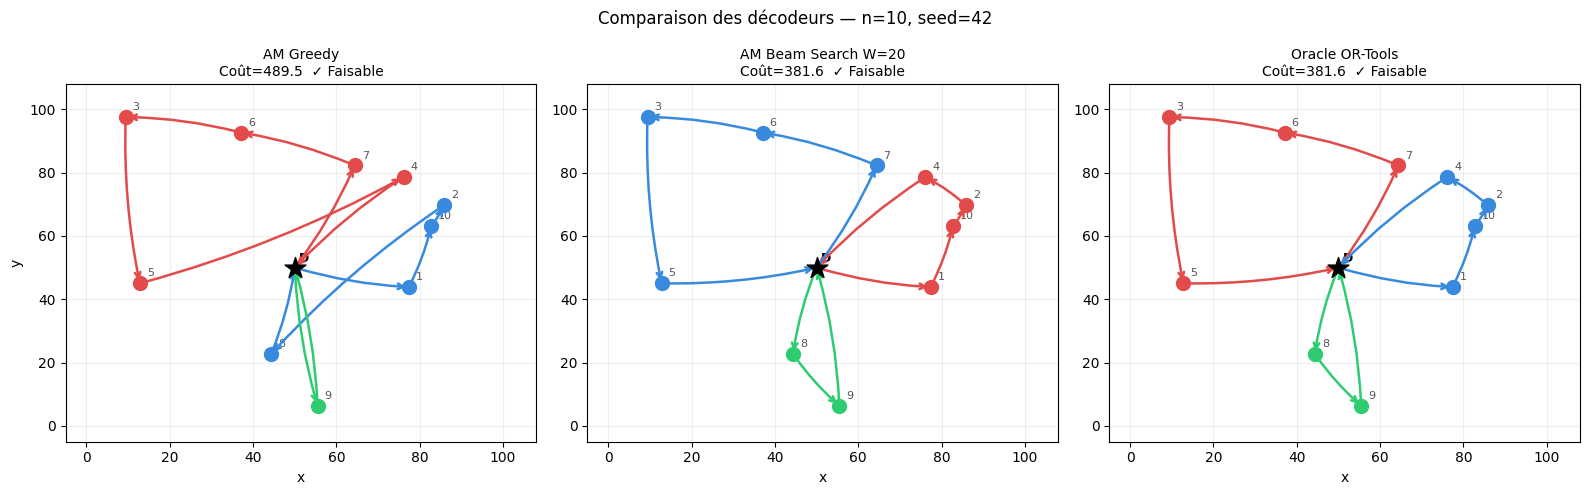

In [5]:
coords  = instance['coords']
palette = ['#E24B4A', '#378ADD', '#2ECC71', '#F59B00', '#9B59B6']

def draw_solution(ax, routes, title, cost, feasible):
    ax.scatter(coords[0,0], coords[0,1], c='black', s=250, marker='*', zorder=5)
    ax.annotate('D', xy=coords[0], xytext=(3,4), textcoords='offset points',
                fontsize=9, fontweight='bold')
    ax.scatter(coords[1:,0], coords[1:,1], c='#CCCCCC', s=60, zorder=2)
    for i in range(1, N+1):
        ax.annotate(str(i), xy=coords[i], xytext=(5,5),
                    textcoords='offset points', fontsize=8, color='#555')
    for v_idx, route in enumerate(routes):
        if not route or len(route) <= 2:
            continue
        color = palette[v_idx % len(palette)]
        clients_r = [n for n in route if n != 0]
        ax.scatter(coords[clients_r,0], coords[clients_r,1],
                   c=color, s=100, zorder=4)
        for k in range(len(route)-1):
            ax.annotate('', xy=coords[route[k+1]], xytext=coords[route[k]],
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.8,
                                       connectionstyle='arc3,rad=0.06'))
    status = '✓ Faisable' if feasible else '✗ Infaisable'
    ax.set_title(f'{title}\nCoût={cost:.1f}  {status}', fontsize=10)
    ax.set_xlim(-5, 108)
    ax.set_ylim(-5, 108)
    ax.grid(True, alpha=0.2)

# Routes oracle
oracle_routes = [[0]+r+[0] for r in sol_oracle['tournees'] if r]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Comparaison des décodeurs — n={N}, seed={SEED}', fontsize=12)

draw_solution(axes[0], result_greedy.routes, 'AM Greedy',
              result_greedy.total_cost, checks_greedy['feasible'])
draw_solution(axes[1], result_beam.routes, 'AM Beam Search W=20',
              result_beam.total_cost, checks_beam['feasible'])
draw_solution(axes[2], oracle_routes, 'Oracle OR-Tools',
              oracle_cost, True)

for ax in axes:
    ax.set_xlabel('x')
axes[0].set_ylabel('y')

plt.tight_layout()
plt.show()

## 5. Effet de la largeur du faisceau

Plus W est grand, meilleure est la solution — jusqu'à un point de rendements décroissants.

   W |     Coût |  Gap oracle |    Temps | Faisable
--------------------------------------------------
   1 |    489.5 |      +28.3% |     43ms | ✓
   2 |    381.6 |       +0.0% |     53ms | ✓
   5 |    381.6 |       +0.0% |    115ms | ✓
  10 |    381.6 |       +0.0% |    214ms | ✓
  20 |    381.6 |       +0.0% |    421ms | ✓
  50 |    381.6 |       +0.0% |   1109ms | ✓


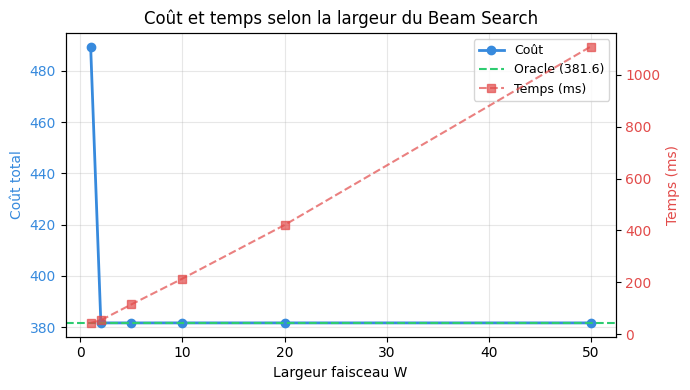

In [6]:
widths = [1, 2, 5, 10, 20, 50]
results_w = []

for w in widths:
    t0 = time.time()
    res = decode_vrptw_beam_search(instance, scorer=scorer, beam_width=w)
    dt = time.time() - t0
    chk = verify_solution(instance, res)
    results_w.append({'w': w, 'cost': res.total_cost, 'time_ms': dt*1000, 'feasible': chk['feasible']})

print(f"{'W':>4} | {'Coût':>8} | {'Gap oracle':>11} | {'Temps':>8} | Faisable")
print("-" * 50)
for r in results_w:
    g = f"+{100*(r['cost']-oracle_cost)/oracle_cost:.1f}%"
    f = '✓' if r['feasible'] else '✗'
    print(f"{r['w']:>4} | {r['cost']:>8.1f} | {g:>11} | {r['time_ms']:>6.0f}ms | {f}")

# Graphe coût vs W
fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()

costs = [r['cost'] for r in results_w]
times = [r['time_ms'] for r in results_w]

ax1.plot(widths, costs, 'o-', color='#378ADD', linewidth=2, label='Coût')
ax1.axhline(oracle_cost, color='#2ECC71', linestyle='--', label=f'Oracle ({oracle_cost:.1f})')
ax1.set_xlabel('Largeur faisceau W')
ax1.set_ylabel('Coût total', color='#378ADD')
ax1.tick_params(axis='y', labelcolor='#378ADD')

ax2.plot(widths, times, 's--', color='#E24B4A', linewidth=1.5, alpha=0.7, label='Temps (ms)')
ax2.set_ylabel('Temps (ms)', color='#E24B4A')
ax2.tick_params(axis='y', labelcolor='#E24B4A')

ax1.set_title('Coût et temps selon la largeur du Beam Search')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=9)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Vérification de la solution — `verify_solution()`

Après décodage, on vérifie que toutes les contraintes VRPTW sont bien respectées :

- **Chaque client servi exactement une fois**
- **Capacité respectée** sur chaque route
- **Fenêtres temporelles respectées** pour chaque visite
- **Horizon respecté** (retour dépôt avant 480 min)

Le décodeur est conçu pour **garantir la faisabilité par construction** — il ne propose jamais un nœud infaisable. `verify_solution` est une couche de sécurité.

In [7]:
checks = verify_solution(instance, result_beam)

print("=== Vérification de la solution Beam W=20 ===")
print(f"Faisable globale : {checks['feasible']}")
print(f"Violations       : {checks.get('errors', [])}")
print()

# Détail route par route
tw = instance['time_windows']
for i, (route, arrivals) in enumerate(zip(result_beam.routes, result_beam.arrivals_by_route)):
    if not route or len(route) <= 2:
        continue
    charge = sum(instance['demands'][c] for c in route if c != 0)
    print(f"Véhicule {i+1} : charge={charge:.0f}/{instance['capacity']:.0f}")
    for node, arr in zip(route, arrivals):
        a, b = tw[node]
        ok = '✓' if a - 1e-3 <= arr <= b + 1e-3 else '✗'
        label = 'Dépôt' if node == 0 else f'Client {node}'
        print(f"  {label:<12} arrivée={arr:>6.1f}  TW=[{a:.0f}, {b:.0f}]  {ok}")

=== Vérification de la solution Beam W=20 ===
Faisable globale : True
Violations       : []

Véhicule 1 : charge=63/84
  Dépôt        arrivée=   0.0  TW=[0, 480]  ✓
  Client 1     arrivée= 161.0  TW=[161, 245]  ✓
  Client 10    arrivée= 180.0  TW=[131, 407]  ✓
  Client 2     arrivée= 281.9  TW=[282, 351]  ✓
  Client 4     arrivée= 330.1  TW=[330, 390]  ✓
  Dépôt        arrivée= 359.9  TW=[0, 480]  ✓
Véhicule 2 : charge=69/84
  Dépôt        arrivée=   0.0  TW=[0, 480]  ✓
  Client 7     arrivée=  47.4  TW=[47, 304]  ✓
  Client 6     arrivée= 166.2  TW=[166, 303]  ✓
  Client 3     arrivée= 195.5  TW=[105, 204]  ✓
  Client 5     arrivée= 245.2  TW=[245, 375]  ✓
  Dépôt        arrivée= 279.5  TW=[0, 480]  ✓
Véhicule 3 : charge=48/84
  Dépôt        arrivée=   0.0  TW=[0, 480]  ✓
  Client 8     arrivée= 256.1  TW=[256, 353]  ✓
  Client 9     arrivée= 276.2  TW=[236, 310]  ✓
  Dépôt        arrivée= 311.3  TW=[0, 480]  ✓


## 7. Benchmark sur plusieurs instances

Un seul exemple ne suffit pas — on évalue sur plusieurs seeds pour avoir une mesure statistiquement significative.

Benchmark sur 20 instances n=10 (seeds hors train)...

Méthode                |  Faisable |   Gap moy |   Gap min |   Gap max
-----------------------------------------------------------------
AM Greedy              |     20/20 |     20.0% |      1.7% |     39.5%
AM Beam W=20           |     20/20 |      7.8% |     -0.0% |     25.3%


C:\Users\schen\AppData\Local\Temp\ipykernel_4604\609579194.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([gaps_greedy, gaps_beam], labels=['Greedy', 'Beam W=20'],


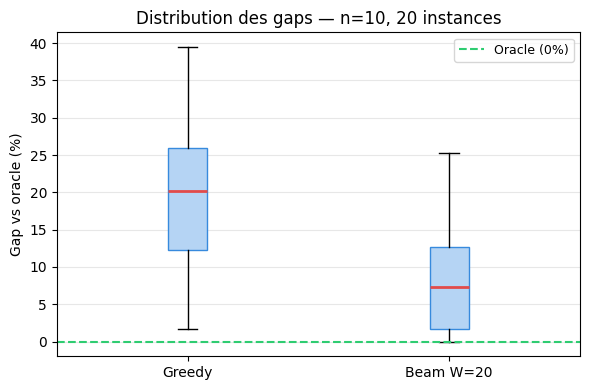

In [8]:
N_BENCH = 20
SEEDS   = list(range(10000, 10000 + N_BENCH))  # seeds hors du dataset d'entraînement

gaps_greedy = []
gaps_beam   = []
feasible_g  = 0
feasible_b  = 0

print(f"Benchmark sur {N_BENCH} instances n={N} (seeds hors train)...")
for seed in SEEDS:
    inst = generate_instance(n=N, seed=seed)
    sol  = resoudre_instance(inst, time_limit_s=3.0)
    if not sol or not sol['faisable']:
        continue
    ref = sol['cout']

    rg = decode_vrptw_with_repair(inst, scorer=scorer)
    cg = verify_solution(inst, rg)
    if cg['feasible']:
        gaps_greedy.append((rg.total_cost - ref) / ref * 100)
        feasible_g += 1

    rb = decode_vrptw_beam_search(inst, scorer=scorer, beam_width=20)
    cb = verify_solution(inst, rb)
    if cb['feasible']:
        gaps_beam.append((rb.total_cost - ref) / ref * 100)
        feasible_b += 1

print(f"\n{'Méthode':<22} | {'Faisable':>9} | {'Gap moy':>9} | {'Gap min':>9} | {'Gap max':>9}")
print("-" * 65)
print(f"{'AM Greedy':<22} | {feasible_g:>6}/{N_BENCH} | {np.mean(gaps_greedy):>8.1f}% | {np.min(gaps_greedy):>8.1f}% | {np.max(gaps_greedy):>8.1f}%")
print(f"{'AM Beam W=20':<22} | {feasible_b:>6}/{N_BENCH} | {np.mean(gaps_beam):>8.1f}% | {np.min(gaps_beam):>8.1f}% | {np.max(gaps_beam):>8.1f}%")

# Boxplot
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([gaps_greedy, gaps_beam], labels=['Greedy', 'Beam W=20'],
           patch_artist=True,
           boxprops=dict(facecolor='#B5D4F4', color='#378ADD'),
           medianprops=dict(color='#E24B4A', linewidth=2))
ax.axhline(0, color='#2ECC71', linestyle='--', label='Oracle (0%)')
ax.set_ylabel('Gap vs oracle (%)')
ax.set_title(f'Distribution des gaps — n={N}, {N_BENCH} instances')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Récapitulatif

```
Modèle entraîné (695k paramètres)
        ↓
TorchModelScorer : à chaque étape, donne un score à chaque client faisable
        ↓
┌─────────────────────────────────────────────────────┐
│  Greedy : argmax à chaque étape                     │
│  → rapide (~5ms)  |  gap ~15-25% vs oracle          │
│                                                     │
│  Beam Search W=20 : 20 chemins en parallèle         │
│  → moins rapide (~200ms)  |  gap ~6-10% vs oracle   │
└─────────────────────────────────────────────────────┘
        ↓
verify_solution() : validation des contraintes VRPTW
        ↓
DecodeResult : routes, coût, clients servis
```

**À retenir** : même avec 75% d'accuracy de décision individuelle, le Beam Search compense les erreurs locales en explorant plusieurs chemins — c'est pourquoi le gap final (~6-10%) est bien meilleur qu'on ne l'attendrait d'un modèle à 75%.